In [ ]:
import sys
import os

# ── Colab detection ───────────────────────────────────────────────────────────
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/ASVspoof2019/notebooks')
    import subprocess
    subprocess.run(['pip', 'install', 'librosa', 'soundfile', '-q'], check=True)
    print('Running on Google Colab | Drive mounted | Dependencies ready.')
except ImportError:
    IN_COLAB = False
    print('Running locally.')

# Audio Preprocessing Pipeline

Before model training, all audio files must be converted into a consistent format.  
This preprocessing pipeline performs the following steps:

1. Load audio files  
2. Convert audio to mono  
3. Resample audio to 16 kHz  
4. Normalize waveform values  
5. Handle variable-length audio using padding and truncation  
6. Create masking support for padded values  
7. Display preprocessing results

## Import Required Libraries

In [2]:
from pathlib import Path
import numpy as np
import librosa
import soundfile as sf
from tqdm import tqdm
import matplotlib.pyplot as plt

## Define Configuration Values


All audio files should have the same sampling rate and length before training.
Every file is resampled to 16 kHz and padded or truncated to exactly **64,600 samples (~4.04 seconds)** — the standard length used in ASVspoof anti-spoofing research.

In [3]:
TARGET_SAMPLE_RATE = 16000
MAX_SAMPLES        = 64600   # 4.04 s @ 16 kHz — standard in ASVspoof anti-spoofing

DATA_ROOT = Path("../data")

INPUT_ROOT  = DATA_ROOT / "raw" / "LA"
OUTPUT_ROOT = DATA_ROOT / "preprocessed" / "LA"

AUDIO_FOLDERS = [
    "ASVspoof2019_LA_train/flac",
    "ASVspoof2019_LA_dev/flac",
    "ASVspoof2019_LA_eval/flac"
]

SUPPORTED_EXTENSIONS = [".flac"]

print("Input Root :", INPUT_ROOT)
print("Output Root:", OUTPUT_ROOT)
print("Max Samples:", MAX_SAMPLES)

Input Root : ../data/raw/LA
Output Root: ../data/preprocessed/LA
Max Samples: 64600


##  Load Audio File

In [4]:
def load_audio(file_path):
    audio, sample_rate = librosa.load(file_path, sr=None, mono=False)
    return audio, sample_rate

## Convert Audio to Mono

Some audio files may be stereo and some may be mono.
A machine learning model needs consistent input, so all audio is converted to mono.

We use mono because it makes audio smaller, consistent, faster to process, and still keeps the important speech information.

In [5]:
def convert_to_mono(audio):
    if audio.ndim > 1:
        audio = np.mean(audio, axis=0)
    return audio

## Resample Audio to 16 kHz

Different audio files can have different sample rates such as 44.1 kHz, 22.05 kHz, or 48 kHz.
We resample all files to 16 kHz so the model receives consistent audio input.

16 kHz is used because it keeps important speech information while reducing file size, memory usage, and training cost.

In [6]:
def resample_audio(audio, original_sample_rate, target_sample_rate=TARGET_SAMPLE_RATE):
    if original_sample_rate != target_sample_rate:
        audio = librosa.resample(
            y=audio,
            orig_sr=original_sample_rate,
            target_sr=target_sample_rate
        )
    return audio

## Normalize Waveform

Some recordings may be very loud and some may be very quiet.
Normalization reduces this loudness difference and makes training more stable.

In [7]:
def normalize_waveform(audio):
    max_value = np.max(np.abs(audio))
    if max_value > 0:
        audio = audio / max_value
    return audio

##  Padding and Truncation


Audio files usually have different durations.
Neural networks process data in batches, so all audio inputs must have the same length.

In [8]:
def pad_or_truncate(audio, max_samples=MAX_SAMPLES):
    original_length = len(audio)

    if original_length < max_samples:
        padding_length = max_samples - original_length
        audio = np.pad(audio, (0, padding_length), mode="constant")
    else:
        audio = audio[:max_samples]

    return audio, original_length

## Create Mask for Padded Audio

Padding adds zeros to short audio files.
The mask helps the model or processing pipeline know which part is real audio and which part is padding.

In [9]:
def create_mask(original_length, max_samples=MAX_SAMPLES):
    mask = np.zeros(max_samples)

    valid_length = min(original_length, max_samples)
    mask[:valid_length] = 1

    return mask

## Complete Preprocessing Function

This function combines all preprocessing steps into one reusable function.
Now every audio file will go through the same preprocessing pipeline.

In [10]:
def preprocess_audio(file_path):
    """
    Complete preprocessing pipeline for one audio file.
    """

    # Step 1: Load original audio
    audio, original_sample_rate = load_audio(file_path)

    # Step 2: Convert to mono
    audio = convert_to_mono(audio)

    # Step 3: Resample to 16 kHz
    audio = resample_audio(audio, original_sample_rate)

    # Step 4: Normalize waveform
    audio = normalize_waveform(audio)

    # Step 5: Pad or truncate audio
    audio, original_length = pad_or_truncate(audio)

    # Step 6: Create mask
    mask = create_mask(original_length)

    return {
        "audio": audio,
        "mask": mask,
        "original_sample_rate": original_sample_rate,
        "target_sample_rate": TARGET_SAMPLE_RATE,
        "original_length": original_length,
        "final_length": len(audio)
    }

## Save One Preprocessed File

In [11]:
def preprocess_and_save_file(input_file_path, output_file_path):
    try:
        result = preprocess_audio(input_file_path)

        output_file_path.parent.mkdir(parents=True, exist_ok=True)

        sf.write(
            file=str(output_file_path),
            data=result["audio"],
            samplerate=result["target_sample_rate"]
        )

        return {
            "status": "success",
            "input_file": str(input_file_path),
            "output_file": str(output_file_path),
            "original_sample_rate": result["original_sample_rate"],
            "target_sample_rate": result["target_sample_rate"],
            "original_length": result["original_length"],
            "final_length": result["final_length"]
        }

    except Exception as error:
        return {
            "status": "failed",
            "input_file": str(input_file_path),
            "output_file": str(output_file_path),
            "error": str(error)
        }

# Process Train, Dev, and Eval

In [12]:
def preprocess_asvspoof_la_dataset(input_root, output_root):
    logs = []

    for folder in AUDIO_FOLDERS:
        input_folder = input_root / folder

        audio_files = []

        for ext in SUPPORTED_EXTENSIONS:
            audio_files.extend(input_folder.rglob(f"*{ext}"))

        print(f"\nProcessing folder: {folder}")
        print("Files found:", len(audio_files))

        for input_file_path in tqdm(audio_files, desc=f"Processing {folder}"):
            relative_path = input_file_path.relative_to(input_root)

            output_file_path = output_root / relative_path

            log = preprocess_and_save_file(input_file_path, output_file_path)
            logs.append(log)

    return logs

# Run Preprocessing

In [13]:
logs = preprocess_asvspoof_la_dataset(INPUT_ROOT, OUTPUT_ROOT)


Processing folder: ASVspoof2019_LA_train/flac
Files found: 25380


Processing ASVspoof2019_LA_train/flac: 100%|██████████| 25380/25380 [01:50<00:00, 229.38it/s]



Processing folder: ASVspoof2019_LA_dev/flac
Files found: 24986


Processing ASVspoof2019_LA_dev/flac: 100%|██████████| 24986/24986 [01:08<00:00, 366.32it/s]



Processing folder: ASVspoof2019_LA_eval/flac
Files found: 71933


Processing ASVspoof2019_LA_eval/flac: 100%|██████████| 71933/71933 [03:19<00:00, 360.84it/s]


# Show Summary

In [14]:
success_logs = [log for log in logs if log["status"] == "success"]
failed_logs = [log for log in logs if log["status"] == "failed"]

print("Preprocessing Completed")
print("Successful Files:", len(success_logs))
print("Failed Files:", len(failed_logs))

if failed_logs:
    print("\nFirst 10 Failed Files:")
    for failed in failed_logs[:10]:
        print("File:", failed["input_file"])
        print("Error:", failed["error"])
        print("-" * 80)

Preprocessing Completed
Successful Files: 122299
Failed Files: 0


# Check Saved Folder Counts

In [15]:
for folder in AUDIO_FOLDERS:
    output_folder = OUTPUT_ROOT / folder

    if output_folder.exists():
        files = list(output_folder.rglob("*.flac"))
        print(folder, "saved files:", len(files))
    else:
        print(folder, "not found in output")

ASVspoof2019_LA_train/flac saved files: 25380
ASVspoof2019_LA_dev/flac saved files: 24986
ASVspoof2019_LA_eval/flac saved files: 71933


## sample Visualization

In [16]:
# Pick any available dev file for visualization
dev_flac_dir  = INPUT_ROOT / "ASVspoof2019_LA_dev" / "flac"
sample_files  = sorted(dev_flac_dir.glob("*.flac"))

if not sample_files:
    print("No dev files found — run preprocessing first or check INPUT_ROOT.")
else:
    sample_file_path = sample_files[0]
    print("Visualising:", sample_file_path.name)

    original_audio, original_sr = librosa.load(str(sample_file_path), sr=None, mono=False)

    if original_audio.ndim > 1:
        original_audio_mono = np.mean(original_audio, axis=0)
    else:
        original_audio_mono = original_audio

    processed_result = preprocess_audio(sample_file_path)

    processed_audio = processed_result["audio"]
    processed_sr    = processed_result["target_sample_rate"]

    print("Original Sample Rate :", original_sr)
    print("Processed Sample Rate:", processed_sr)
    print("Original Audio Length:", len(original_audio_mono))
    print("Processed Audio Length:", len(processed_audio))

Visualising: LA_D_1000265.flac
Original Sample Rate : 16000
Processed Sample Rate: 16000
Original Audio Length: 23488
Processed Audio Length: 64600


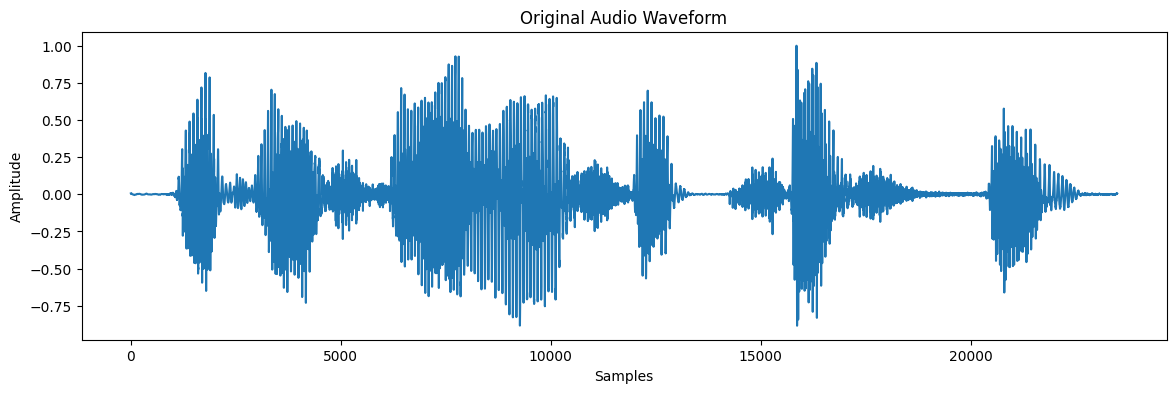

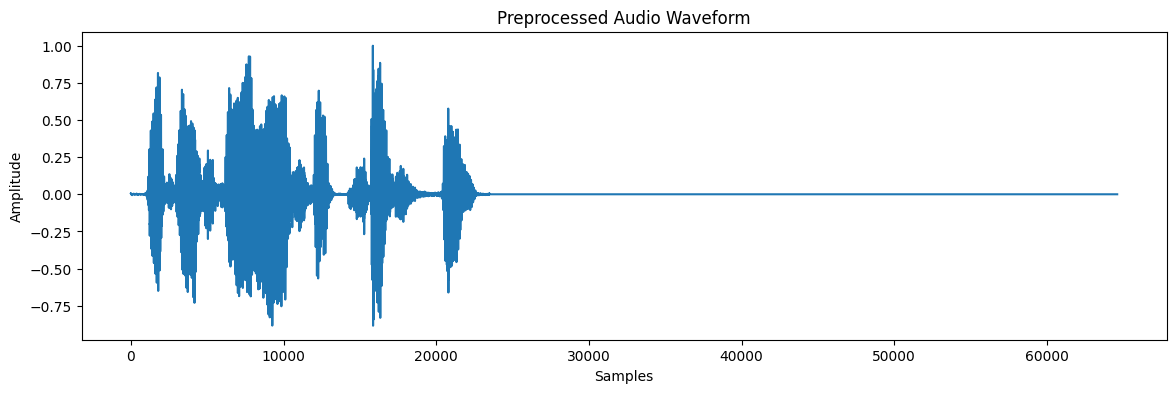

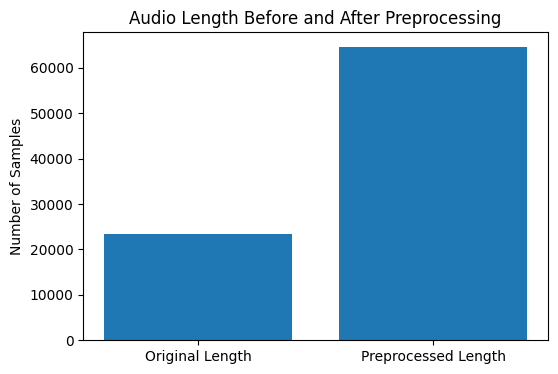

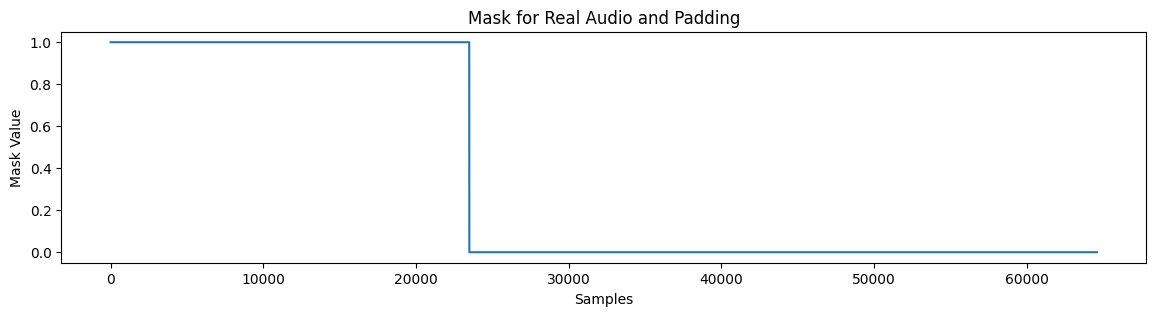

In [17]:
plt.figure(figsize=(14, 4))
plt.plot(original_audio_mono)
plt.title("Original Audio Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()
plt.figure(figsize=(14, 4))
plt.plot(processed_audio)
plt.title("Preprocessed Audio Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()
lengths = [len(original_audio_mono), len(processed_audio)]
labels = ["Original Length", "Preprocessed Length"]

plt.figure(figsize=(6, 4))
plt.bar(labels, lengths)
plt.title("Audio Length Before and After Preprocessing")
plt.ylabel("Number of Samples")
plt.show()

mask = create_mask(processed_result["original_length"])

plt.figure(figsize=(14, 3))
plt.plot(mask)
plt.title("Mask for Real Audio and Padding")
plt.xlabel("Samples")
plt.ylabel("Mask Value")
plt.show()


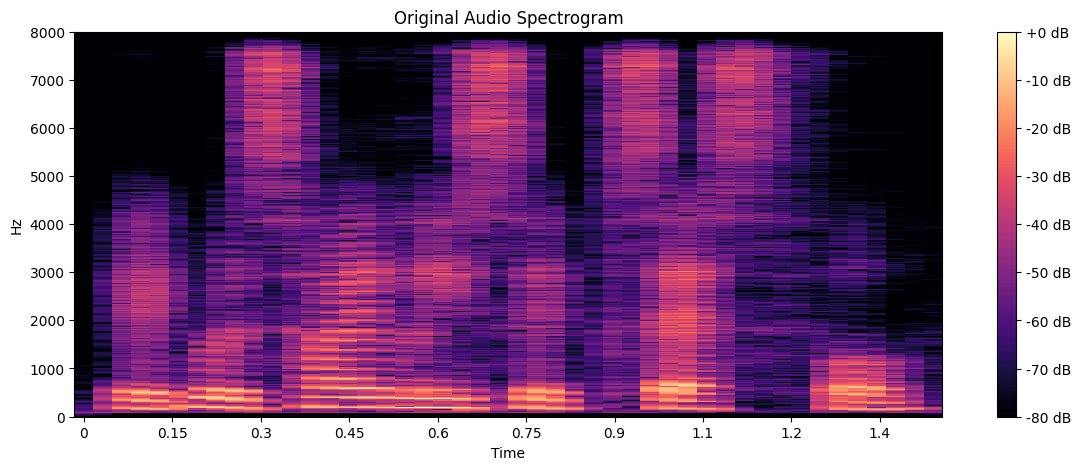

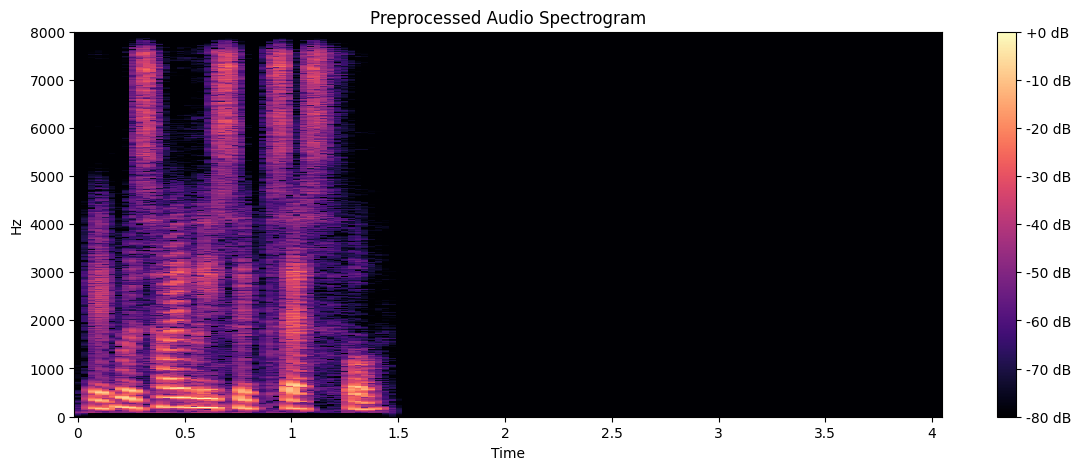

In [18]:
original_spectrogram = librosa.amplitude_to_db(
    np.abs(librosa.stft(original_audio_mono)),
    ref=np.max
)

plt.figure(figsize=(14, 5))
librosa.display.specshow(
    original_spectrogram,
    sr=original_sr,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Original Audio Spectrogram")
plt.show()
processed_spectrogram = librosa.amplitude_to_db(
    np.abs(librosa.stft(processed_audio)),
    ref=np.max
)

plt.figure(figsize=(14, 5))
librosa.display.specshow(
    processed_spectrogram,
    sr=processed_sr,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Preprocessed Audio Spectrogram")
plt.show()

Before Normalization
  Sample Rate      : 16000
  Min Value        : -0.8847656
  Max Value        : 0.9999695
  Max Absolute Val : 0.9999695
After Normalization
  Min Value        : -0.8847926
  Max Value        : 1.0
  Max Absolute Val : 1.0


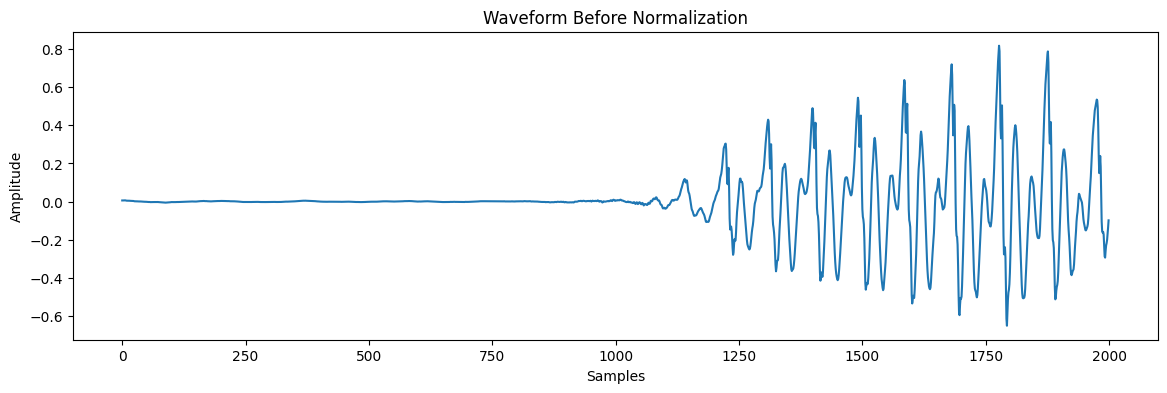

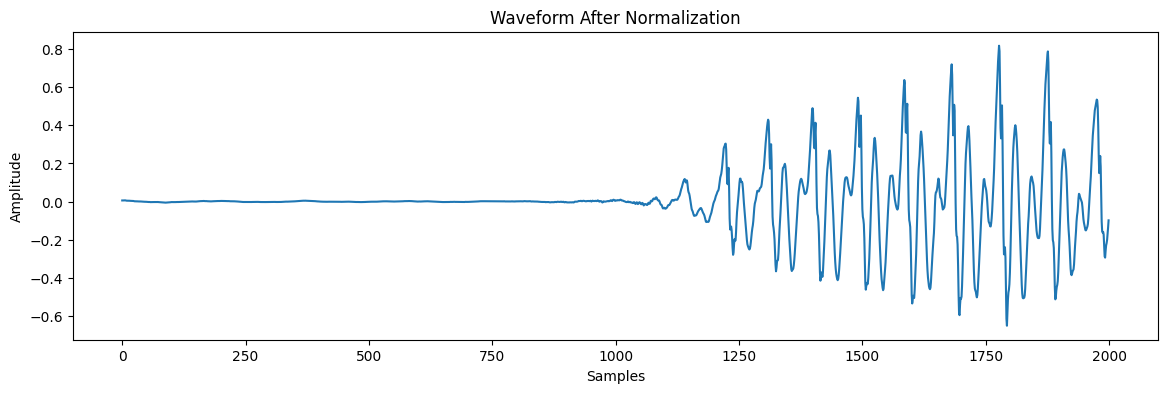

In [19]:
if not sample_files:
    print("No dev files found — skip this cell.")
else:
    audio, sr = librosa.load(str(sample_file_path), sr=None, mono=False)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=0)

    normalized_audio = normalize_waveform(audio)

    print("Before Normalization")
    print("  Sample Rate      :", sr)
    print("  Min Value        :", np.min(audio))
    print("  Max Value        :", np.max(audio))
    print("  Max Absolute Val :", np.max(np.abs(audio)))
    print("After Normalization")
    print("  Min Value        :", np.min(normalized_audio))
    print("  Max Value        :", np.max(normalized_audio))
    print("  Max Absolute Val :", np.max(np.abs(normalized_audio)))

    samples_to_show = 2000

    plt.figure(figsize=(14, 4))
    plt.plot(audio[:samples_to_show])
    plt.title("Waveform Before Normalization")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(normalized_audio[:samples_to_show])
    plt.title("Waveform After Normalization")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.show()